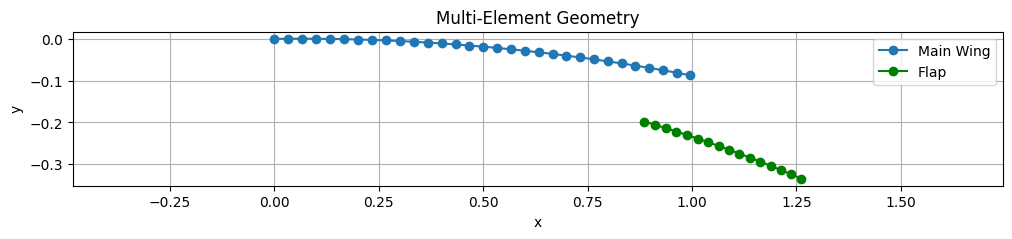

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# 1. main parameters

# Angle 1: Global Pitch (Tilts the Main Wing AND the Flap together)
alpha_wing_deg = 5
alpha_wing = np.radians(alpha_wing_deg)

# Angle 2: Local Flap Deflection (Tilts ONLY the flap relative to the wing)
flap_angle_deg = -15
flap_deflection = np.radians(flap_angle_deg)

# Angle 3: Freestream Wind Angle (Tilts the incoming air)
alpha_wind_deg = 0
alpha_wind = np.radians(alpha_wind_deg)

# System Parameters
N = 30
N_flap = 15
N_total = N + N_flap
U_inf = 1.0


# 2. BUILD LOCAL GEOMETRY

x_panel_flat = np.linspace(0 , 1 , N+1)
y_panel_flat = 0.1 * x_panel_flat * (1 - x_panel_flat)

flap_chord = 0.4
x_flap_local = np.linspace(0, flap_chord, N_flap + 1)
y_flap_local = (0.06 * x_flap_local * (1 - x_flap_local / flap_chord))


# 3. APPLY LOCAL FLAP DEFLECTION

x_flap_def = (x_flap_local * np.cos(flap_deflection)) - (y_flap_local * np.sin(flap_deflection))
y_flap_def = (x_flap_local * np.sin(flap_deflection)) + (y_flap_local * np.cos(flap_deflection))

flap_shift_x = 0.9
flap_shift_y = -0.12
x_flap_assembled = x_flap_def + flap_shift_x
y_flap_assembled = y_flap_def + flap_shift_y


# 4. APPLY GLOBAL WING PITCH

x_panel = (x_panel_flat * np.cos(-alpha_wing)) - (y_panel_flat * np.sin(-alpha_wing))
y_panel = (x_panel_flat * np.sin(-alpha_wing)) + (y_panel_flat * np.cos(-alpha_wing))

x_flap = (x_flap_assembled * np.cos(-alpha_wing)) - (y_flap_assembled * np.sin(-alpha_wing))
y_flap = (x_flap_assembled * np.sin(-alpha_wing)) + (y_flap_assembled * np.cos(-alpha_wing))

# Plot the camber surface
plt.figure(figsize=(12,2))
plt.plot(x_panel, y_panel, marker='o', label='Main Wing')
plt.plot(x_flap, y_flap, '-o', color='green', label='Flap')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Multi-Element Geometry")
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

In [2]:

# 5. COLLOCATION & VORTEX POINTS

x_vortex = 0.75 * x_panel[:-1] + 0.25 * x_panel[1:]
y_vortex = 0.75 * y_panel[:-1] + 0.25 * y_panel[1:]
x_collocation = 0.25 * x_panel[:-1] + 0.75 * x_panel[1:]
y_collocation = 0.25 * y_panel[:-1] + 0.75 * y_panel[1:]

x_vortex_flap = 0.75 * x_flap[:-1] + 0.25 * x_flap[1:]
y_vortex_flap = 0.75 * y_flap[:-1] + 0.25 * y_flap[1:]
x_collocation_flap = 0.25 * x_flap[:-1] + 0.75 * x_flap[1:]
y_collocation_flap = 0.25 * y_flap[:-1] + 0.75 * y_flap[1:]


# 6. NORMAL VECTORS

def get_vectors(x, y, N_points):
    dx = np.diff(x)
    dy = np.diff(y)
    length = np.sqrt(dx**2 + dy**2)
    tx = dx / length
    ty = dy / length
    nx = -ty
    ny = tx
    return tx, ty, nx, ny

tx, ty, nx, ny = get_vectors(x_panel, y_panel, N)
tx_flap, ty_flap, nx_flap, ny_flap = get_vectors(x_flap, y_flap, N_flap)

x_vortex_total = np.concatenate((x_vortex, x_vortex_flap))
y_vortex_total = np.concatenate((y_vortex, y_vortex_flap))
x_collocation_total = np.concatenate((x_collocation, x_collocation_flap))
y_collocation_total = np.concatenate((y_collocation, y_collocation_flap))
tx_total = np.concatenate((tx, tx_flap))
ty_total = np.concatenate((ty, ty_flap))
nx_total = np.concatenate((nx, nx_flap))
ny_total = np.concatenate((ny, ny_flap))


# 7. INFLUENCE MATRIX (A) T

A = np.zeros((N_total, N_total))

for i in range(N_total):
    for j in range(N_total):
        delx = x_collocation_total[i] - x_vortex_total[j]
        dely = y_collocation_total[i] - y_vortex_total[j]
        r_squared = max(delx**2 + dely**2, 1e-10)

        u = (1 / (2*np.pi)) * (dely / r_squared)
        v = -(1 / (2*np.pi)) * (delx / r_squared)

        A[i,j] = (u * nx_total[i] + v * ny_total[i])


# 8. RIGHT HAND SIDE (b) AND SOLVE

b = np.zeros(N_total)
for i in range(N_total):
    b[i] = -(U_inf * np.cos(alpha_wind) * nx_total[i] + U_inf * np.sin(alpha_wind) * ny_total[i])

Gamma = np.linalg.solve(A, b)

Gamma_total = np.sum(Gamma)
CL = 2 * Gamma_total
print(f"Total circulation = {Gamma_total:.4f}")
print(f"Lift coefficient CL = {CL:.4f}")

Total circulation = 0.9769
Lift coefficient CL = 1.9537


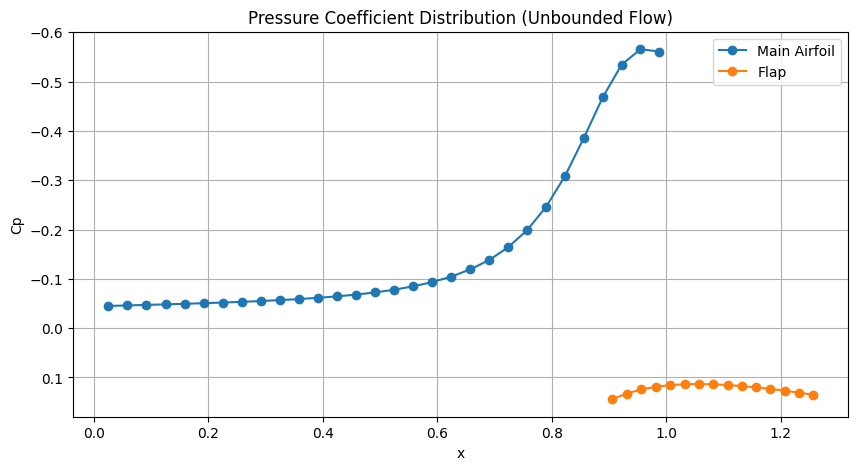

In [3]:

# 9. TANGENTIAL VELOCITY & CP

Vt = np.zeros(N_total)

for i in range(N_total):
    Vt[i] = (U_inf * np.cos(alpha_wind) * tx_total[i] + U_inf * np.sin(alpha_wind) * ty_total[i])

    for j in range(N_total):
        delx = x_collocation_total[i] - x_vortex_total[j]
        dely = y_collocation_total[i] - y_vortex_total[j]
        r_squared = max(delx**2 + dely**2, 1e-10)

        u = (Gamma[j] / (2*np.pi)) * (dely / r_squared)
        v = -(Gamma[j] / (2*np.pi)) * (delx / r_squared)

        Vt[i] += (u * tx_total[i] + v * ty_total[i])

Cp = 1 - (Vt/U_inf)**2

plt.figure(figsize=(10,5))
plt.plot(x_collocation_total[:N], Cp[:N], '-o', label='Main Airfoil')
plt.plot(x_collocation_total[N:], Cp[N:], '-o', label='Flap')
plt.gca().invert_yaxis()
plt.xlabel('x')
plt.ylabel('Cp')
plt.title('Pressure Coefficient Distribution (Unbounded Flow)')
plt.grid(True)
plt.legend()
plt.show()

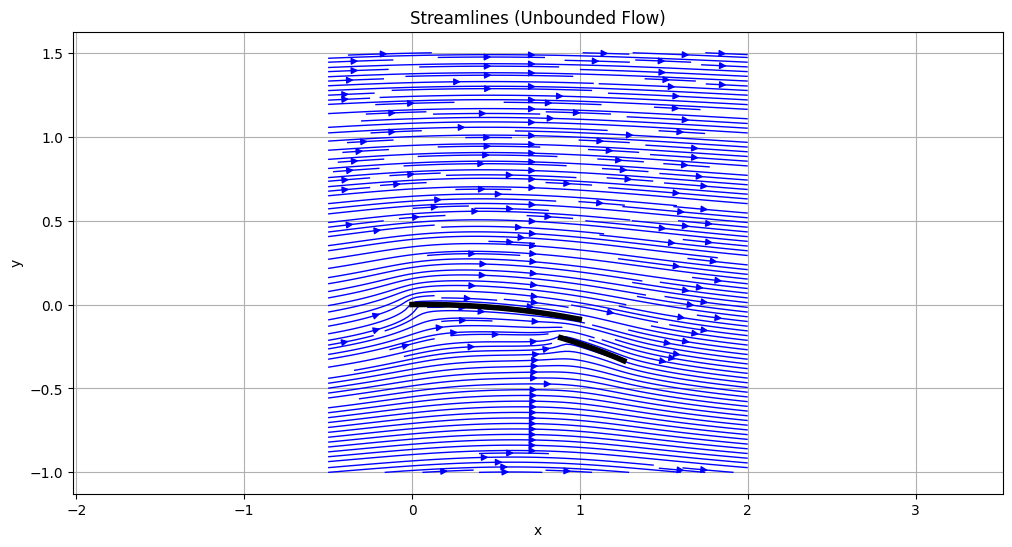

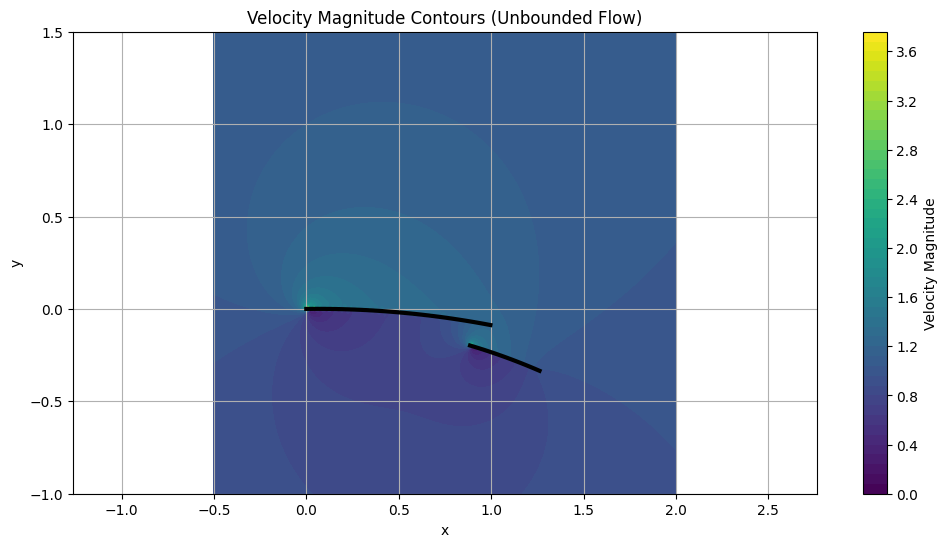

In [4]:

# 10. STREAMLINES & VELOCITY FIELD

X, Y = np.meshgrid(
    np.linspace(-0.5, 2.0, 250),
    np.linspace(-1.0, 1.5, 250)
)

U = U_inf * np.cos(alpha_wind) * np.ones_like(X)
V = U_inf * np.sin(alpha_wind) * np.ones_like(Y)

for j in range(N_total):
    delx = X - x_vortex_total[j]
    dely = Y - y_vortex_total[j]
    r_squared = delx**2 + dely**2
    r_squared[r_squared < 1e-10] = 1e-10

    u_induced = (Gamma[j] / (2*np.pi)) * (dely / r_squared)
    v_induced = -(Gamma[j] / (2*np.pi)) * (delx / r_squared)

    U += u_induced
    V += v_induced

velocity_magnitude = np.sqrt(U**2 + V**2)

plt.figure(figsize=(12,6))
plt.streamplot(X, Y, U, V, density=3, linewidth=1, color='blue')
plt.plot(x_panel, y_panel, '-k', linewidth=4)
plt.plot(x_flap, y_flap, '-k', linewidth=4)
plt.axis('equal')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Streamlines (Unbounded Flow)')
plt.grid(True)
plt.show()

plt.figure(figsize=(12,6))
contour = plt.contourf(X, Y, velocity_magnitude, levels=60, cmap='viridis')
plt.colorbar(contour, label='Velocity Magnitude')
plt.plot(x_panel, y_panel, '-k', linewidth=3)
plt.plot(x_flap, y_flap, '-k', linewidth=3)
plt.axis('equal')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Velocity Magnitude Contours (Unbounded Flow)')
plt.grid(True)
plt.show()